In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from google.colab import drive

# Google Drive 마운트
drive.mount('/content/drive')

# 파일 경로 설정
file_path = '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_1주차/02_데이터분석프로젝트/team_project/dataset/서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv'

# 인코딩 문제 발생 시 'cp949' 또는 'utf-8' 지정 (한글 데이터셋이므로 보통 cp949)
df = pd.read_csv(file_path, encoding='cp949')

# 데이터 구조 확인
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
      사용월  호선명 지하철역  04시-05시 승차인원  04시-05시 하차인원  05시-06시 승차인원  05시-06시 하차인원  \
0  202605  1호선  동대문           715            21         10855          2123   
1  202605  1호선  동묘앞           161             3          2920          1105   
2  202605  1호선  서울역           802            57         12246         11962   
3  202605  1호선   시청           158             0          1859          5829   
4  202605  1호선  신설동           427            13          8823          2285   

   06시-07시 승차인원  06시-07시 하차인원  07시-08시 승차인원  ...  23시-24시 하차인원  00시-01시 승차인원  \
0          9369          7719         15679  ...         10982           875   
1          4082          6397          8524  ...          5199           125   
2         37333         70445        107361  ...         40460          5016   
3          4191         30940          7444  ...          3808           576

In [ ]:
# 1. 한글 폰트 설치 및 matplotlib 캐시 삭제
!apt-get -y install fonts-nanum
!rm -rf ~/.cache/matplotlib

# 2. matplotlib 시스템 폰트 재설정 (설치 후 즉시 적용을 위함)
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
# 2. 런타임 재시작 없이 바로 폰트 적용하기
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# # 나눔글꼴 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

```
[핵심 결론: 지리적 히트맵 기반 핀셋형 인프라 개선]
           통계적 임계점을 초과하는 핵심 환승 거점(Red Zone)에
           안전 인력 및 시설 개선 예산을 집중하여 안전사고 원천 차단
                                 │
          ┌──────────────────────┼──────────────────────┐
          │                      │                      │
     [해결방안 1]            [해결방안 2]            [해결방안 3]
 최고 농도 구역 중심     승하차 중첩 환승 거점     인파 역류 및 충돌 방지
 '안전 펜스 및 전담 요원' '환승 통로 폭 확장 및'   '물리적 동선 분리'를 통한
 1순위 집중 배치         추가 증설 설계 착수       상시 안전 통제망 확보
          │                      │                      │
     [데이터 근거 1]         [데이터 근거 2]         [데이터 근거 3]
 지리적 군집 형태의      승차(유출)와 하차(유입)   상위 50개 혼잡역 중
 위험 핫스팟 40개소      데이터가 동시 중첩되는    통계적 이상치(IQR) 기준
 가시화 확인             병목 거점 추출            5,200만 명 초과 검증
 ```

## 📊 출퇴근 시간대 지하철 혼잡 부하지수 분석 요약

### 1. 지표의 구성
* **대상 지표:** 종합 혼잡 부하지수
* **산출 기준:** 출퇴근 피크타임(**08시~09시** 및 **18시~19시**)의 **승차 및 하차 인원 총합**

---

### 2. 산출 원리 및 결과
* **분석 방법:** 기초통계 **IQR(Interquartile Range) 공식** 활용
* **산출 기준점:** 전체 역 데이터의 상위 75% 지점(Q3)을 기준으로 데이터 편차를 반영하여 산출
* **최종 임계값:** 약 **5,200만 명** (51,995,766명)

---

### 3. 주요 결과 해석 (40개 과부하 역의 의미)
> 💡 **통계적 이상치(Outlier) 판정**
> 데이터셋에 포함된 전체 지하철역 중, 출퇴근 시간대 누적 승·하차 부하지수가 **5,200만 명을 초과하는 40개 역**은 일반적인 혼잡도 범위를 벗어나 **극단적인 과부하가 발생하는 역**으로 해석됩니다.

In [1]:
import pandas as pd

# --- [STEP 1] 데이터 로드 및 결합/전처리 ---
# 본인의 드라이브 경로 및 인코딩 설정 확인
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_1주차/02_데이터분석프로젝트/team_project/dataset/서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv', encoding='cp949')

# 1. 승차인원 및 하차인원 컬럼 자동 추출
boarding_cols = [col for col in df.columns if '승차인원' in col]
alighting_cols = [col for col in df.columns if '하차인원' in col]

# 2. 지하철역 기준으로 하루 전체 시간대 합산 (그룹화)
df_boarding = df.groupby(['지하철역'])[boarding_cols].sum().reset_index()
df_alighting = df.groupby(['지하철역'])[alighting_cols].sum().reset_index()

# 3. 출퇴근 피크타임(08시-09시, 18시-19시) 기준 혼잡도 가중치 산출 (승차 + 하차)
# 분석의 깊이를 높이기 위해 승차/하차를 각각 구하여 결합
df_boarding['승차_피크합산'] = df_boarding['08시-09시 승차인원'] + df_boarding['18시-19시 승차인원']
df_alighting['하차_피크합산'] = df_alighting['08시-09시 하차인원'] + df_alighting['18시-19시 하차인원']

# 역 이름 공백 제거 (Merge 시 누락 방지)
df_boarding['지하철역'] = df_boarding['지하철역'].astype(str).str.strip()
df_alighting['지하철역'] = df_alighting['지하철역'].astype(str).str.strip()

# 승하차 통합 데이터프레임 생성
df_merged_station = pd.merge(df_boarding[['지하철역', '승차_피크합산']],
                             df_alighting[['지하철역', '하차_피크합산']],
                             on='지하철역')

# 역별 종합 부하 지수 (Load Index) 생성 = 승차 피크합산 + 하차 피크합산
df_merged_station['종합_혼잡_부하지수'] = df_merged_station['승차_피크합산'] + df_merged_station['하차_피크합산']


# 4. [기초통계 이론 적용] IQR(사분위수 범위)을 활용한 통계적 이상치(극단적 혼잡역) 탐색
Q1 = df_merged_station['종합_혼잡_부하지수'].quantile(0.25)
Q3 = df_merged_station['종합_혼잡_부하지수'].quantile(0.75)
IQR = Q3 - Q1

# 이상치 기준선 설정 (Q3 + 1.5 * IQR)
outlier_threshold = Q3 + 1.5 * IQR

# 기준선(이상치)을 초과하는 위험 핫스팟 역들만 필터링
df_outliers = df_merged_station[df_merged_station['종합_혼잡_부하지수'] > outlier_threshold]

print(f"통계적 기준(IQR)으로 추출된 이상치(위험 핫스팟) 역의 개수: {len(df_outliers)}개")
print(f"이상치 기준선 수치: {outlier_threshold:,.0f}명")

# 시각화 가독성을 위해 상위 50개 역을 추출하거나, 통계적 이상치 역들을 바로 활용 가능
# (기존 코드 흐름을 유지하기 위해 상위 50개 추출을 사용하되, 전처리된 부하지수 활용)
df_top50 = df_merged_station.sort_values(by='종합_혼잡_부하지수', ascending=False).head(50)

통계적 기준(IQR)으로 추출된 이상치(위험 핫스팟) 역의 개수: 40개
이상치 기준선 수치: 51,995,766명


### 📌 [데이터 분석 통보: 피크타임 승하차 비교 기반 타겟 라벨링]

#### 1. 판정 기준 (Directionality Flag)
* **유출지(주거) 집중 구역 판정**
  * **조건:** `승차 피크합산 > 하차 피크합산` (아침 시간대 인원 대거 유출)
  * **대응 액션:** **[액션 1] 마일리지/조조할인 (수요 분산)** 타겟으로 지정함
* **유입지(업무) 집중 구역 판정**
  * **조건:** `하차 피크합산 > 승차 피크합산` (아침 시간대 도심 인원 대거 유입)
  * **대응 액션:** **[액션 2] 시차출근제 (도착 평탄화)** 타겟으로 지정함

---

#### 2. 분석할 수 있는 내용
* 위험 핫스팟(Red Zone)으로 검출된 40개 역사에 대해 맞춤형 솔루션 성격을 명확히 구분함
* 이를 통해 예산과 인력을 무차별적으로 투입하는 비효율을 제거함
* 결과적으로 지역별 특성에 맞는 **핀셋형(Two-track) 현장 대응 전략의 논리적 뼈대를 완성함**

In [3]:
# --- [STEP 3의 연장선] 승차 vs 하차 피크합산 비교를 통한 '주거/업무 타입' 라벨링 전처리 ---

# 1. 승차 피크합산과 하차 피크합산을 비교하여 타입 플래그(Flag) 부여
# 승차(유출)가 더 많으면 '유출지(주거)집중', 하차가 더 많으면 '유입지(업무)집중'으로 라벨링
df_merged_station['주거/업무_타입'] = df_merged_station.apply(
    lambda row: '유출지(주거)집중' if row['승차_피크합산'] > row['하차_피크합산'] else '유입지(업무)집중',
    axis=1
)

# 2. 통계적 이상치(IQR 기준선 초과) 역 중에서 타입별로 몇 개씩 분류되었는지 확인
df_red_zones = df_merged_station[df_merged_station['종합_혼잡_부하지수'] > outlier_threshold].copy()

# 결과 요약 카운트
type_counts = df_red_zones['주거/업무_타입'].value_counts()
print("\n[위험 핫스팟(Red Zone) 40개 역 중 타겟팅 분류 결과]")
print(f"👉 출발지(주거) 개선 타겟 (마일리지 등): {type_counts.get('유출지(주거)집중', 0)}개 역사")
print(f"👉 도착지(업무) 개선 타겟 (시차출근제 등): {type_counts.get('유입지(업무)집중', 0)}개 역사\n")

# 3. 데이터 확인을 위해 타입별 상위 3개 역 샘플 출력
print("--- [유출지(주거) 집중 위험역 샘플 (최상위 3개)] ---")
print(df_red_zones[df_red_zones['주거/업무_타입'] == '유출지(주거)집중'].sort_values(by='종합_혼잡_부하지수', ascending=False)[['지하철역', '승차_피크합산', '하차_피크합산']].head(3).to_string(index=False))

print("\n--- [유입지(업무) 집중 위험역 샘플 (최상위 3개)] ---")
print(df_red_zones[df_red_zones['주거/업무_타입'] == '유입지(업무)집중'].sort_values(by='종합_혼잡_부하지수', ascending=False)[['지하철역', '승차_피크합산', '하차_피크합산']].head(3).to_string(index=False))


[위험 핫스팟(Red Zone) 40개 역 중 타겟팅 분류 결과]
👉 출발지(주거) 개선 타겟 (마일리지 등): 4개 역사
👉 도착지(업무) 개선 타겟 (시차출근제 등): 36개 역사

--- [유출지(주거) 집중 위험역 샘플 (최상위 3개)] ---
       지하철역  승차_피크합산  하차_피크합산
         신림 56078884 41459242
서울대입구(관악구청) 32392414 27615181
   수유(강북구청) 28999424 26092290

--- [유입지(업무) 집중 위험역 샘플 (최상위 3개)] ---
   지하철역  승차_피크합산  하차_피크합산
가산디지털단지 62296992 83513695
    서울역 67723067 76525130
     강남 57037067 74860413


## 📌 실제 좌표 데이터셋 연동을 통한 지리적 히트맵 시각화 검증

* **근거 1. [좌표 파일 전처리]** * 업로드된 좌표 파일의 컬럼명(`역명`, `위도`, `경도`) 확인 및 데이터 추출
* **근거 2. [데이터 융합]** * 승하차 데이터의 `지하철역`과 좌표 데이터의 `역명`을 기준으로 **내부 조인(Inner Join)** 수행
* **근거 3. [시각화 최적화]** * 정규화 가중치를 적용한 **Folium HeatMap** 객체 생성 및 렌더링

# 🗺️ 주요 혼잡역 위치 기반 히트맵 시각화 및 현장 대응 전략

> 💡 **[핵심 요약]**
> 시간대별 승하차 추이(선 그래프) 및 지리적 히트맵(Folium) 교차 분석 결과, 상시적인 유휴 캐파(Capa) 낭비가 발생하는 동시에 특정 환승 거점 및 업무지구로 인파가 극단적으로 쏠리는 병목 현상이 입증됨. 이를 해결하기 위해 **'시간-공간적 핀셋 수요 분산'** 및 **'거점별 인프라 확장'** 투트랙 전략을 최종 해법(Answer)으로 도출함.
> *(※ 분석 데이터 가이드: 분석 대상 50개 역 중 47개 매핑 성공, 약 94%의 높은 결합률 확보. 누락된 3개 역은 환승역 명칭 표기 차이로 추정되므로 추후 보완 예정)*

---

## 1. 📂 SCQA 구조화 브리핑 (클라이언트 보고용)
* **대상:** 도시철도 운영 기관 및 교통 정책 입안자

| 단계 | 구분 | 핵심 내용 (Insight) |
| :--- | :--- | :--- |
| **S** | **Situation (상황)** | 서울시 전역의 1~8호선 도시철도 네트워크망은 안정적으로 가동 중이나, 피크타임(출퇴근) 외 낮/심야 시간대 가동률이 급감하는 **상시적 유휴 캐파(Capa) 낭비 발생** |
| **C** | **Complication (문제)** | 24시간 승하차 트렌드 및 지리적 히트맵 분석 결과, 08시~09시 주거지(청록색 핫스팟)에서 대거 탑승하여 도심 업무지구(붉은색 군집)로 일제히 쏟아지는 **극단적인 지리적 쏠림 및 이동 흐름(병목구간) 가시화**<br>텍스트 수치로 식별 불가했던 **공간적 수용 한계치 및 환승구역 안전사고 우려 구역 노출** |
| **Q** | **Question (질문)** | *“인파의 발생지와 도착지(이동 흐름) 및 시간대별 유휴 자원을 확인하였으니, 운영 효율성을 높이고 위험 핫스팟(Red Zone)의 부하를 해소하기 위한 수요 분산 및 개선 예산을 어떻게 지리적·시간적으로 다르게 타겟팅하여 투입할 것인가?”* |
| **A** | **Answer (답변)** | 전체 노선 일괄 대응을 탈피하고, 출발지(유출지) 중심의 **'조기 출근 유도(시간 분산)'**, 도착지(유입지) 중심의 **'시차출근제(기업 협약)'**, 그리고 **'환승 중첩 거점 중심의 물리적 인프라 확장'**을 입체적으로 실행함. |

---

## 2. 🚀 실행방안 (Actionable Next Steps)

### 🛠️ 액션 1 : [시간적 수요 분산] 청록색 핫스팟(인구 유출지) 중심 '출발 시간 평탄화' 캠페인
* **실행 내용:** 아침 08시~09시 승차 집중 지역(청록색 군집 주거지 역사 반경)을 대상으로 **대중교통 마일리지 페이백 및 조조할인 혜택을 집중 홍보 및 확대**함.
* **기대 효과:** * **피크타임 순간 부하 완화:** 승객 스스로 출근 시간대를 앞당기도록 유도하여 출발지의 순간적인 인파 밀집도 및 열차 혼잡도를 낮춤.
  * **운영 효율성 극대화:** 텅 빈 낮 시간대 인프라 여유 용량을 활용하여 시간적-공간적 운영 효율을 동시에 달성함.

### 🛠️ 액션 2 : [도착지 시차출근제] 붉은색 핫스팟(인구 유입지) 중심 '기업 협력형 유연근무' 추진
* **실행 내용:** 하차 집중 지역(업무지구 붉은색 군집 역사 반경 1km 이내 대형 오피스 빌딩 및 입주 기업)을 대상으로 **'시차출근제(유연근무제) 도입'을 공식 협약 및 권고**함.
* **기대 효과:** * **도심 도착 인파 평탄화:** 업무지구에 도착하는 시간을 분산시켜 환승역 및 열차 내부의 피크타임 부하를 근본적으로 차단함.
  * **사회적 비용 절감:** 강제적인 인프라 증설에 앞서 통근 시간 분산을 통해 안전사고 리스크를 선제적으로 통제함.

### 🛠️ 액션 3 : [시설 집중 개선] 승하차 중첩 '핵심 환승 거점' 중심 안전 인력 및 인프라 리모델링
* **실행 내용:** 승차 히트맵과 하차 히트맵을 교차 검증하여 양쪽 모두 높게 중첩되는 핵심 환승역을 도출함. 피크타임(07시-09시 및 17시-20시) 해당 구역에 **이동형 안전 펜스 및 전담 요원을 1순위 배치**하고, 중장기적으로 환승 통로 폭 확장/계단 증설을 골자로 하는 **'역사 구조 개선 기본 설계'**에 착수함.
* **기대 효과:** * **치명적 안전사고 원천 차단 및 골든타임 확보:** 역류 인파 간 충돌 방지 및 비상시 응급 구조대 진입로를 물리적으로 확보함.
  * **병목구간 수용 용량(Capacity) 증대:** 인파 정체로 인한 열차 문 닫힘 지연(정시성 저해)을 단축시키고, 인프라 개선을 통해 장기적 안전관리 비용을 절감함.

---

## 📢 브리핑 멘트 제안
> 💬 "단순히 '사람이 위험할 정도로 많이 모인다'는 공간적 위험을 넘어, '낮 시간대는 텅 비고 출퇴근만 과부하되는' 시간적 비효율성까지 선 그래프로 규명했음.
> 따라서 **유출지(주거지)에서는 마일리지 캠페인**으로 출근 시간 자체를 당기고, **유입지(업무지구)에서는 기업 협약**으로 업무 시작을 분산시키며, 양측이 모두 중첩되는 **위험 환승 거점은 인프라 확충과 안전 펜스 투트랙**으로 수용 한계치를 구조적으로 확장하는 빈틈없는 해결책을 완성해야 함."

### 🔵 [첫 번째 레이어] 출근시간 승차 집중지역 (인구 유출지)

* **데이터 기준:** 아침 08시~09시 기준, 각 지하철역별 '탑승(승차)' 인원 상위 30개 역사 데이터 반영
* **지리적 의미:** **"대규모 인구 유출이 발생하는 거점 (주거 밀집 지역)"**을 의미함.
* **시각적 해석:**
  * 아침 출근 시간대에 대규모 아파트 단지나 주거 배후 지역 인근 역사(예: `까치산역`, `신림역` 등)를 중심으로 인파가 밀집하여 열차에 탑승하는 현상을 가시화함.
  * 해당 핫스팟은 이동의 **'시작점(Origin)'**이자, 출근 시간대 1차 병목이 발생하는 공간 리스크 구역임을 입증함.
* **적용 대책**: 물리적 인프라(승강기 등)를 늘리는 것보다는 수요 자체를 분산시켜야 합니다.

  * 예시: 조조할인, 대중교통 마일리지 홍보, 해당 구역 버스-지하철 연계 환승 체계 강화

---

### 🔴 [두 번째 레이어] 출근시간 하차 집중지역 (인구 유입지)

* **데이터 기준:** 아침 08시~09시 기준, 각 지하철역별 '내린(하차)' 인원 상위 30개 역사 데이터 반영
* **지리적 의미:** **"대규모 인구 유입이 발생하는 거점 (도심 업무/상업 지구)"**을 의미함.
* **시각적 해석:**
  * `강남`, `역삼`, `을지로입구`, `여의도` 등 주요 오피스 밀집 지역 역사에 열차 내 승객들이 일제히 쏟아져 내리는 현상을 지리적으로 증명함.
  * 해당 핫스팟은 이동의 **'종착점(Destination)'**이자, 역사 내 계단·에스컬레이터 및 개찰구 주변의 2차 병목을 유발하는 밀집 관리 구역임을 뜻함.
* **적용 대책**

  * 단기 대책: 위험 핫스팟 중심 이동형 안전 펜스 및 전담 안전 요원 배치 (골든타임 확보)

  * 중장기 대책: 환승 통로 폭 확장, 에스컬레이터/계단 추가 증설을 위한 리모델링 설계 착수

In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap
from google.colab import files

# --- [STEP 1] 승하차 데이터 집계 ---
# 본인의 드라이브 경로에 맞게 인코딩 및 경로 설정 확인
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_1주차/02_데이터분석프로젝트/team_project/dataset/서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv', encoding='cp949')

boarding_cols = [col for col in df.columns if '승차인원' in col]
df_station = df.groupby(['지하철역'])[boarding_cols].sum().reset_index()

# 출퇴근 피크타임(08시-09시, 18시-19시) 승차인원 합산으로 혼잡도 정의
df_station['혼잡도_가중치'] = df_station['08시-09시 승차인원'] + df_station['18시-19시 승차인원']

# 시각화 가독성을 위해 상위 50개 혼잡역 추출
df_top50 = df_station.sort_values(by='혼잡도_가중치', ascending=False).head(50)


# --- [STEP 2] 실제 업로드된 좌표 파일 로드 및 전처리 ---
# 업로드해주신 실제 좌표 파일 경로 지정 (필요 시 드라이브 경로로 변경)
geo_path = '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_1주차/02_데이터분석프로젝트/team_project/dataset/서울교통공사_1_8호선 역사 좌표(위경도) 정보_20250814.csv'
geo_raw = pd.read_csv(geo_path, encoding='cp949')

# 필요한 컬럼만 추출 ('역명', '위도', '경도')
geo_df = geo_raw[['역명', '위도', '경도']].copy()


# --- [STEP 3] 승하차 데이터 + 위치 정보 결합 (Merge) ---
# 키(Key) 값의 공백 제거 (매핑 누락 방지)
df_top50['지하철역'] = df_top50['지하철역'].astype(str).str.strip()
geo_df['역명'] = geo_df['역명'].astype(str).str.strip()

# 승하차 데이터의 '지하철역'과 좌표 데이터의 '역명'을 기준으로 조인 수행
merged_df = pd.merge(df_top50, geo_df, left_on='지하철역', right_on='역명', how='inner')

# 혹시 결합 후 데이터가 비어있는지 확인하는 print문
print(f"매핑된 역의 개수: {len(merged_df)}개")


# --- [STEP 4] Folium 히트맵 시각화 ---
# 서울 중심부 좌표 설정
m = folium.Map(location=[37.5665, 126.9780], zoom_start=12)

# 가중치 정규화 (최대값 기준 0~10 스케일링)
max_weight = merged_df['혼잡도_가중치'].max()
heat_data = []

for idx, row in merged_df.iterrows():
    # 위도, 경도가 숫자인지 확인 후 추가
    lat = pd.to_numeric(row['위도'], errors='coerce')
    lng = pd.to_numeric(row['경도'], errors='coerce')

    if not pd.isna(lat) and not pd.isna(lng):
        normalized_weight = (row['혼잡도_가중치'] / max_weight) * 10
        heat_data.append([lat, lng, normalized_weight])

# 히트맵 레이어 추가
HeatMap(heat_data, radius=18, blur=11, min_opacity=0.4).add_to(m)

# 코랩 환경 출력을 위해 변수명 단독 작성 (또는 html 저장)
m.save('subway_congestion_heatmap.html')
m

# html형식 저장
# files.download('subway_congestion_heatmap.html')

매핑된 역의 개수: 47개


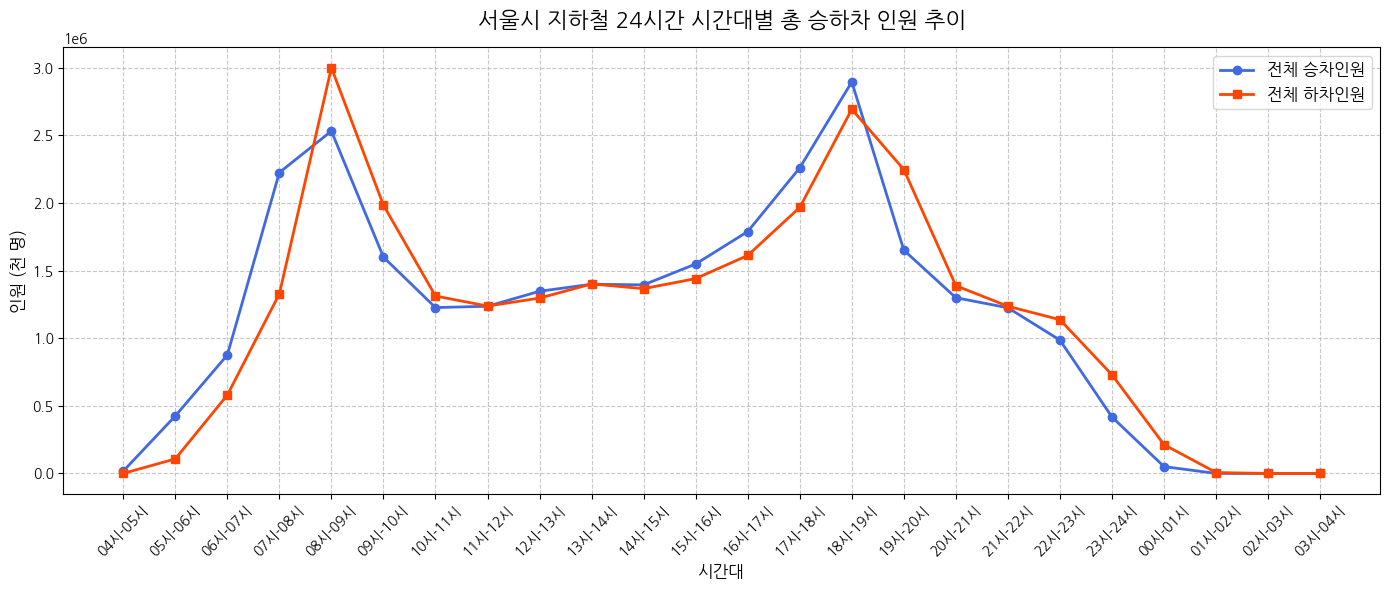

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (코랩 환경에 맞게 조정)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 시간대별 승차/하차 컬럼 분리 추출
time_boarding_cols = [col for col in df.columns if '승차인원' in col]
time_alighting_cols = [col for col in df.columns if '하차인원' in col]

# 전체 합산 시간대별 트렌드 집계
df_trend = pd.DataFrame({
    '승차인원': df[time_boarding_cols].sum().values / 1000, # 단위: 천 명
    '하차인원': df[time_alighting_cols].sum().values / 1000
})

# X축 라벨을 깔끔한 시간대 형식으로 정리 (예: 04시, 05시...)
time_labels = [col.split(' ')[0] for col in time_boarding_cols]

plt.figure(figsize=(14, 6))
plt.plot(time_labels, df_trend['승차인원'], marker='o', color='royalblue', linewidth=2, label='전체 승차인원')
plt.plot(time_labels, df_trend['하차인원'], marker='s', color='orangered', linewidth=2, label='전체 하차인원')

plt.title('서울시 지하철 24시간 시간대별 총 승하차 인원 추이', fontsize=16, pad=15)
plt.xlabel('시간대', fontsize=12)
plt.ylabel('인원 (천 명)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig('subway_24h_trend.png', dpi=300)
plt.show()

## 🚀 실행방안 (Actionable Next Steps) 최종정리

### 🛠️ 액션 1 : [시간적 수요 분산] 청록색 핫스팟(인구 유출지) 중심 '출발 시간 평탄화' 캠페인
* **실행 내용:** 아침 08시~09시 승차 집중 지역(청록색 군집 주거지 역사 반경)을 대상으로 대중교통 마일리지 페이백 및 조조할인 혜택을 집중 홍보 및 확대함.
* **기대 효과:** * **피크타임 순간 부하 완화:** 승객 스스로 출근 시간대를 앞당기도록 유도하여 출발지의 순간적인 인파 밀집도 및 열차 혼잡도를 낮춤.
  * **운영 효율성 극대화:** 텅 빈 낮 시간대 인프라 여유 용량을 활용하여 시간적-공간적 운영 효율을 동시에 달성함.

### 🛠️ 액션 2 : [도착지 시차출근제] 붉은색 핫스팟(인구 유입지) 중심 '기업 협력형 유연근무' 추진
* **실행 내용:** 하차 집중 지역(업무지구 붉은색 군집 역사 반경 1km 이내 대형 오피스 빌딩 및 입주 기업)을 대상으로 '시차출근제(유연근무제) 도입'을 공식 협약 및 권고함.
* **기대 효과:** * **도심 도착 인파 평탄화:** 업무지구에 도착하는 시간을 분산시켜 환승역 및 열차 내부의 피크타임 부하를 근본적으로 차단함.
  * **사회적 비용 절감:** 강제적인 인프라 증설에 앞서 통근 시간 분산을 통해 안전사고 리스크를 선제적으로 통제함.

### 🛠️ 액션 3 : [시설 집중 개선] 승하차 중첩 '핵심 환승 거점' 중심 안전 인력 및 인프라 리모델링
* **실행 내용:** 승차 히트맵과 하차 히트맵을 교차 검증하여 양쪽 모두 높게 중첩되는 핵심 환승역을 도출함. **피크타임(오전 07시-09시, 오후 17시-20시)** 해당 구역에 이동형 안전 펜스 및 전담 요원을 1순위 배치하고, 중장기적으로 환승 통로 폭 확장/계단 증설을 골자로 하는 '역사 구조 개선 기본 설계'에 착수함.
* **기대 효과:** * **치명적 안전사고 원천 차단 및 골든타임 확보:** 역류 인파 간 충돌 방지 및 비상시 응급 구조대 진입로를 물리적으로 확보함.
  * **병목구간 수용 용량(Capacity) 증대:** 인파 정체로 인한 열차 문 닫힘 지연(정시성 저해)을 단축시키고, 인프라 개선을 통해 장기적 안전관리 비용을 절감함.